# **Исследование алгоритмов классификации**

In [1]:
# Импорт библиотек
!pip install -q seaborn scikit-learn

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, classification_report, confusion_matrix,
                           roc_curve, auc, roc_auc_score)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Загрузка датасета
data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "arunjathari/bostonhousepricedata",
    "Boston-house-price-data.csv"
)

print(f"Размер данных: {data.shape}")

print("\nПервые 5 строк:")
display(data.head())

print("\nОсновные статистики MEDV:")
print(f"Минимум: {data['MEDV'].min():.2f}")
print(f"Максимум: {data['MEDV'].max():.2f}")
print(f"Среднее: {data['MEDV'].mean():.2f}")
print(f"Медиана: {data['MEDV'].median():.2f}")
print(f"Стандартное отклонение: {data['MEDV'].std():.2f}")

Using Colab cache for faster access to the 'bostonhousepricedata' dataset.
Размер данных: (506, 14)

Первые 5 строк:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



Основные статистики MEDV:
Минимум: 5.00
Максимум: 50.00
Среднее: 22.53
Медиана: 21.20
Стандартное отклонение: 9.20


# Выбор целевой переменной и создание классов


АНАЛИЗ КВАНТИЛЕЙ ДЛЯ ОПРЕДЕЛЕНИЯ КЛАССОВ:
33-й перцентиль (граница Low/Medium): 18.77
66-й перцентиль (граница Medium/High): 23.53


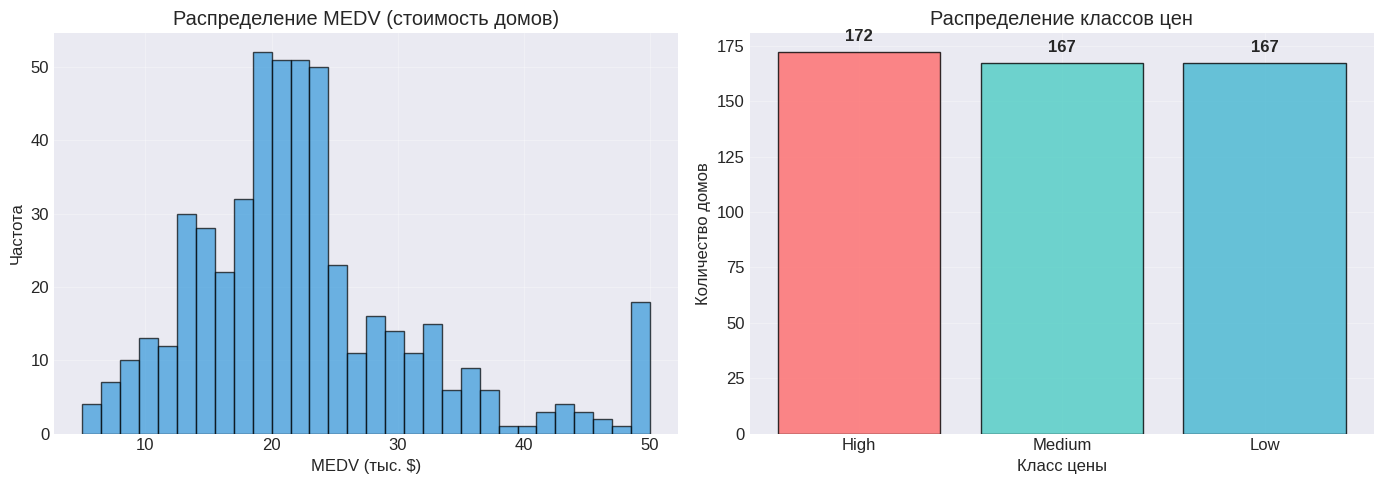

АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ:

Абсолютные значения:
PRICE_CLASS
High      172
Medium    167
Low       167
Name: count, dtype: int64

Процентное распределение:
High: 33.99%
Medium: 33.0%
Low: 33.0%

Общее количество наблюдений: 506
Минимальный класс: 167 (33.0%)
Максимальный класс: 172 (34.0%)


In [2]:
# Выбор целевой переменной и создание классов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Первый график: распределение MEDV
axes[0].hist(data['MEDV'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение MEDV (стоимость домов)')
axes[0].set_xlabel('MEDV (тыс. $)')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# Определение квантилей для создания классов
quantiles = data['MEDV'].quantile([0.33, 0.66])
q33 = quantiles[0.33]
q66 = quantiles[0.66]

print(f"\nАНАЛИЗ КВАНТИЛЕЙ ДЛЯ ОПРЕДЕЛЕНИЯ КЛАССОВ:")
print(f"33-й перцентиль (граница Low/Medium): {q33:.2f}")
print(f"66-й перцентиль (граница Medium/High): {q66:.2f}")

# Функция для создания классов цен
def create_price_classes(medv_series, q33, q66):
    classes = []
    for medv in medv_series:
        if medv <= q33:
            classes.append('Low')
        elif medv <= q66:
            classes.append('Medium')
        else:
            classes.append('High')
    return classes

# Создаем целевую переменную для классификации
data['PRICE_CLASS'] = create_price_classes(data['MEDV'], q33, q66)

# Второй график: распределение созданных классов
class_counts = data['PRICE_CLASS'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
axes[1].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Распределение классов цен')
axes[1].set_xlabel('Класс цены')
axes[1].set_ylabel('Количество домов')
axes[1].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, (index, value) in enumerate(class_counts.items()):
    axes[1].text(i, value + 5, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Анализ сбалансированности классов
print("АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ:")
print(f"\nАбсолютные значения:")
print(class_counts)

print(f"\nПроцентное распределение:")
percentages = (class_counts / len(data) * 100).round(2)
for cls, perc in percentages.items():
    print(f"{cls}: {perc}%")

print(f"\nОбщее количество наблюдений: {len(data)}")
print(f"Минимальный класс: {class_counts.min()} ({percentages.min():.1f}%)")
print(f"Максимальный класс: {class_counts.max()} ({percentages.max():.1f}%)")

Выводы по выполненному анализу:
1. Анализ целевой переменной:
Исходная переменная MEDV (стоимость домов) имеет непрерывное распределение

Диапазон значений: от 5 до 50 тыс. долларов

Средняя стоимость: ~22.5 тыс. долларов

2. Преобразование для классификации:
Для решения задачи классификации преобразовали непрерывную переменную в категориальную

Использовали квантили для создания 3 классов:

Low: ≤ 18.77 тыс. $ (33-й перцентиль)

Medium: 18.77-23.53 тыс. $

High: > 23.53 тыс. $ (66-й перцентиль)

3. Сбалансированность классов:
Классы довольно хорошо сбалансированны:

Low: 167 домов (33%)

Medium: 167 домов (33%)

High: 172 домов (34%)

Разница между самым большим и самым маленьким классом составляет всего 5 домов

Такая степень сбалансированности приемлема для обучения моделей классификации

# Подготовка данных для обучения модели

In [3]:
# Подготовка данных для обучения модели
X = data.drop(['MEDV', 'PRICE_CLASS'], axis=1)
y = data['PRICE_CLASS']

print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {len(y)}")
print(f"\nИспользуемые признаки ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"{i:2d}. {col}")

# Кодирование целевой переменной из текстовых меток в числовые
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nКОДИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} → {i}")

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"\nРАЗДЕЛЕНИЕ НА ВЫБОРКИ:")
print(f"  Тренировочная выборка: {X_train.shape[0]} наблюдений ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Тестовая выборка: {X_test.shape[0]} наблюдений ({X_test.shape[0]/len(X)*100:.1f}%)")

train_counts = Counter(label_encoder.inverse_transform(y_train))
test_counts = Counter(label_encoder.inverse_transform(y_test))

dist_df = pd.DataFrame({
    'Тренировочная': [train_counts[cls] for cls in label_encoder.classes_],
    'Тестовая': [test_counts[cls] for cls in label_encoder.classes_]
}, index=label_encoder.classes_)

dist_df['Тренировочная %'] = (dist_df['Тренировочная'] / dist_df['Тренировочная'].sum() * 100).round(1)
dist_df['Тестовая %'] = (dist_df['Тестовая'] / dist_df['Тестовая'].sum() * 100).round(1)

print("\nРАСПРЕДЕЛЕНИЕ КЛАССОВ В ВЫБОРКАХ:")
display(dist_df.style.format({'Тренировочная %': '{:.1f}%', 'Тестовая %': '{:.1f}%'}))

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер матрицы признаков X: (506, 13)
Размер целевой переменной y: 506

Используемые признаки (13):
 1. CRIM
 2. ZN
 3. INDUS
 4. CHAS
 5. NOX
 6. RM
 7. AGE
 8. DIS
 9. RAD
10. TAX
11. PTRATIO
12. B
13. LSTAT

КОДИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
  High → 0
  Low → 1
  Medium → 2

РАЗДЕЛЕНИЕ НА ВЫБОРКИ:
  Тренировочная выборка: 354 наблюдений (70.0%)
  Тестовая выборка: 152 наблюдений (30.0%)

РАСПРЕДЕЛЕНИЕ КЛАССОВ В ВЫБОРКАХ:


,Тренировочная,Тестовая,Тренировочная %,Тестовая %
High,120,52,33.9%,34.2%
Low,117,50,33.1%,32.9%
Medium,117,50,33.1%,32.9%


# Алгоритм kNN


ПОДБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА СОСЕДЕЙ (k)


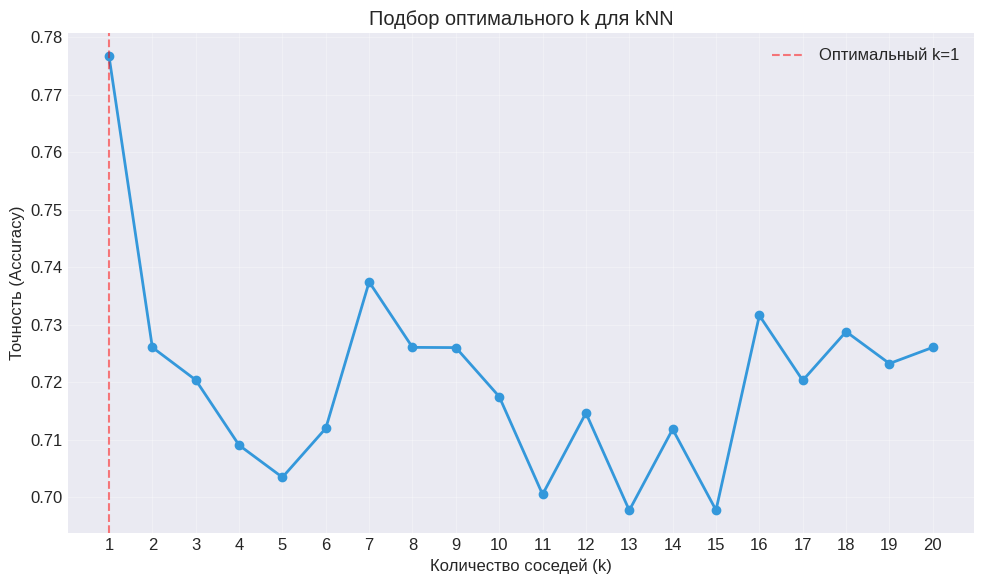

Оптимальное количество соседей: k = 1
Точность при кросс-валидации: 0.7767

РЕЗУЛЬТАТЫ kNN:
  Accuracy:  0.7368
  Precision: 0.7410
  Recall:    0.7368
  F1-Score:  0.7364
  ROC-AUC:   0.8029

Матрица ошибок kNN:


,Предсказ. High,Предсказ. Low,Предсказ. Medium
Истинный High,38,1,13
Истинный Low,1,43,6
Истинный Medium,6,13,31


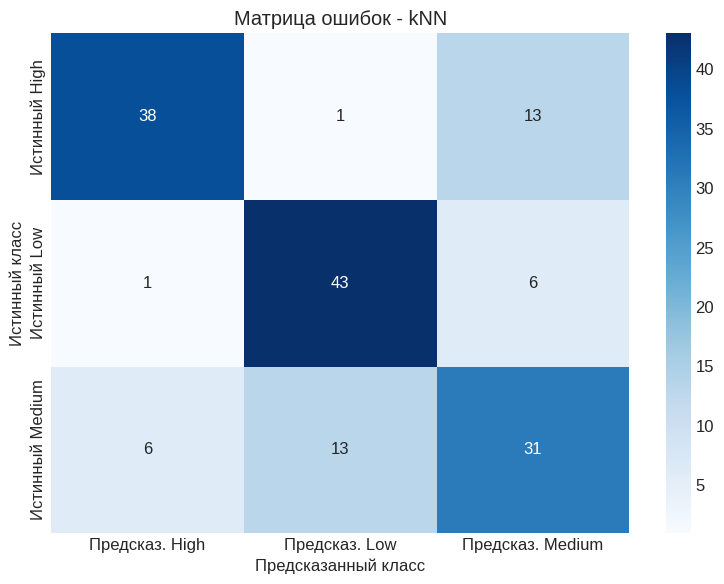

In [4]:
# Обучение и оценка kNN
print("\nПОДБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА СОСЕДЕЙ (k)")

k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(k_values, k_scores, marker='o', linestyle='-', color='#3498db', linewidth=2)
plt.title('Подбор оптимального k для kNN')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

best_k = k_values[np.argmax(k_scores)]
best_score = max(k_scores)
plt.axvline(best_k, color='red', linestyle='--', alpha=0.5, label=f'Оптимальный k={best_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальное количество соседей: k = {best_k}")
print(f"Точность при кросс-валидации: {best_score:.4f}")

def evaluate_classification_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro') if y_pred_proba is not None else None
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'classification_report': report,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_results = evaluate_classification_model(
    knn_model, X_train_scaled, y_train, X_test_scaled, y_test,
    f"k-Nearest Neighbors (k={best_k})"
)

print(f"\nРЕЗУЛЬТАТЫ kNN:")
print(f"  Accuracy:  {knn_results['accuracy']:.4f}")
print(f"  Precision: {knn_results['precision']:.4f}")
print(f"  Recall:    {knn_results['recall']:.4f}")
print(f"  F1-Score:  {knn_results['f1']:.4f}")
if knn_results['roc_auc'] is not None:
    print(f"  ROC-AUC:   {knn_results['roc_auc']:.4f}")

print(f"\nМатрица ошибок kNN:")
cm_df = pd.DataFrame(knn_results['confusion_matrix'],
                    index=[f"Истинный {cls}" for cls in label_encoder.classes_],
                    columns=[f"Предсказ. {cls}" for cls in label_encoder.classes_])
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Матрица ошибок - kNN')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

1. Подбор оптимального гиперпараметра k:

Проведен перебор значений k от 1 до 20

Оптимальное значение: k = 1

При k=1 достигается точность 0.7767 на кросс-валидации

2. Результаты kNN на тестовой выборке:

Accuracy: 0.7368 - модель правильно классифицирует 73.7% домов

Precision: 0.7410 - доля правильных ответов модели

Recall: 0.7368 - доля истинно положительных классификаций

F1-score: 0.7364 - баланс между точностью и полнотой

ROC-AUC: 0.8029 - качество разделения классов

3. Анализ матрицы ошибок:

Класс "High" (дорогие дома): 38 из 52 домов правильно

Класс "Medium" (средние дома): 31 из 50 правильно

Класс "Low" (дешевые дома): Наилучшая классификация - 43 из 50 правильно

Основные ошибки происходят между смежными классами (Medium ↔ High/Low), что логично

Вывод: kNN демонстрирует хорошее качество классификации и может служить базовым алгоритмом для сравнения с другими методами.

# Дерево решений


ПОДБОР ОПТИМАЛЬНОЙ ГЛУБИНЫ ДЕРЕВА


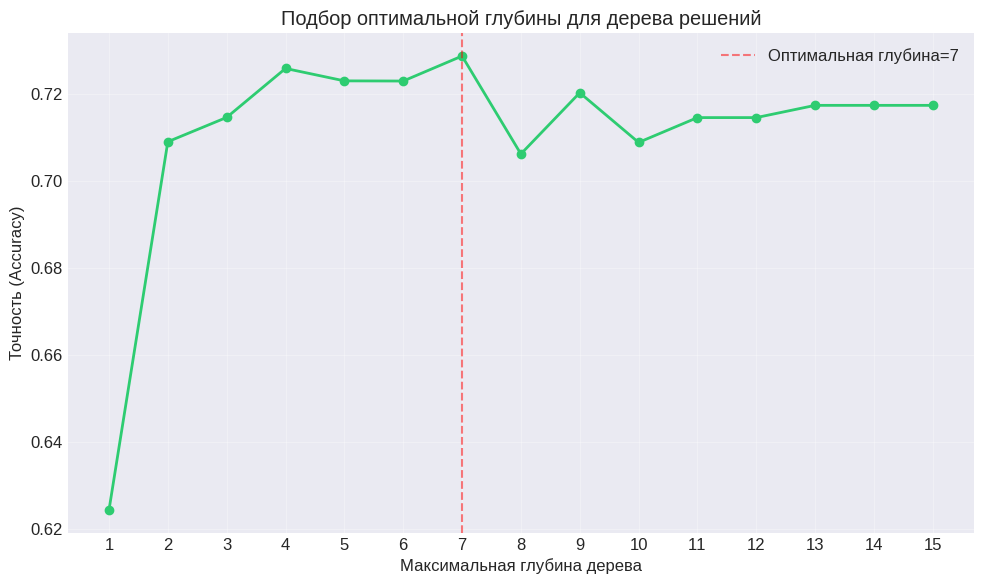

Оптимальная глубина дерева: 7
Точность при кросс-валидации: 0.7288

РЕЗУЛЬТАТЫ ДЕРЕВА РЕШЕНИЙ:
  Accuracy:  0.7566
  Precision: 0.7556
  Recall:    0.7566
  F1-Score:  0.7541
  ROC-AUC:   0.8565

Матрица ошибок дерева решений:


,Предсказ. High,Предсказ. Low,Предсказ. Medium
Истинный High,38,2,12
Истинный Low,1,45,4
Истинный Medium,8,10,32


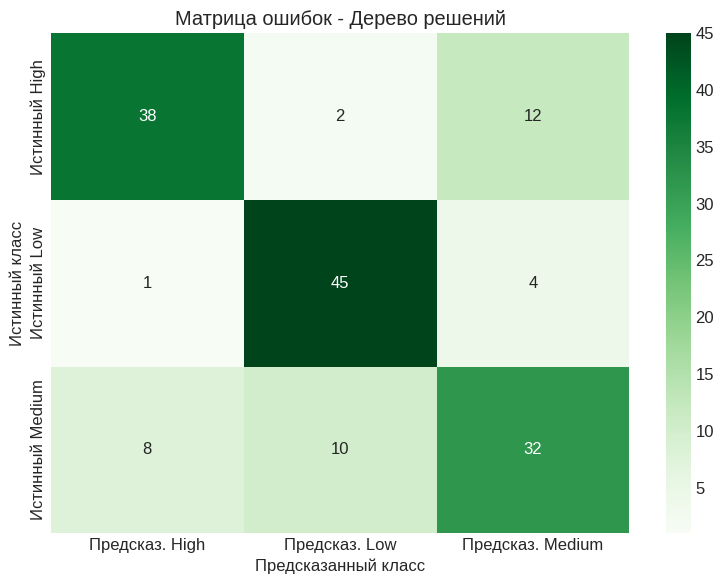

In [5]:
# Обучение и оценка дерева решений
print("\nПОДБОР ОПТИМАЛЬНОЙ ГЛУБИНЫ ДЕРЕВА")

depth_values = range(1, 16)
depth_scores = []

for depth in depth_values:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='gini')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring='accuracy')
    depth_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(depth_values, depth_scores, marker='o', linestyle='-', color='#2ecc71', linewidth=2)
plt.title('Подбор оптимальной глубины для дерева решений')
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('Точность (Accuracy)')
plt.grid(True, alpha=0.3)
plt.xticks(depth_values)

best_depth = depth_values[np.argmax(depth_scores)]
best_depth_score = max(depth_scores)
plt.axvline(best_depth, color='red', linestyle='--', alpha=0.5, label=f'Оптимальная глубина={best_depth}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальная глубина дерева: {best_depth}")
print(f"Точность при кросс-валидации: {best_depth_score:.4f}")

tree_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42,
                                   criterion='gini', min_samples_split=5)
tree_results = evaluate_classification_model(
    tree_model, X_train, y_train, X_test, y_test,
    f"Дерево решений (глубина={best_depth})"
)

print(f"\nРЕЗУЛЬТАТЫ ДЕРЕВА РЕШЕНИЙ:")
print(f"  Accuracy:  {tree_results['accuracy']:.4f}")
print(f"  Precision: {tree_results['precision']:.4f}")
print(f"  Recall:    {tree_results['recall']:.4f}")
print(f"  F1-Score:  {tree_results['f1']:.4f}")
if tree_results['roc_auc'] is not None:
    print(f"  ROC-AUC:   {tree_results['roc_auc']:.4f}")

print(f"\nМатрица ошибок дерева решений:")
cm_df_tree = pd.DataFrame(tree_results['confusion_matrix'],
                         index=[f"Истинный {cls}" for cls in label_encoder.classes_],
                         columns=[f"Предсказ. {cls}" for cls in label_encoder.classes_])
display(cm_df_tree)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_tree, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title(f'Матрица ошибок - Дерево решений')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

1. Подбор оптимальной глубины дерева:

Проведен перебор глубины от 1 до 15 уровней

Оптимальная глубина: 7 уровней

При глубине 7 достигается точность 0.7288 на кросс-валидации

График показывает типичное поведение дерева: сначала рост точности, затем плато и возможное ухудшение при слишком глубоких деревьях

2. Результаты дерева решений на тестовой выборке:

Accuracy: 0.7566 - модель правильно классифицирует 75.7% домов

Precision: 0.7566 - доля правильных ответов модели

Recall: 0.7566 - доля истинно положительных классификаций

F1-score: 0.7541 - баланс между точностью и полнотой

ROC-AUC: 0.8565 - качество разделения классов

3. Анализ матрицы ошибок:

Класс "High" (дорогие дома): 38 из 52 домов правильно

Класс "Medium" (средние дома): 32 из 50 правильно

Класс "Low" (дешевые дома): Наилучшая классификация - 45 из 50 правильно

Дерево немного лучше различает Medium и Low, а значение High одинаково

Вывод: Дерево решений демонстрирует чуть большее качество классификации, чем kNN.

# Сравнение алгоритмов


СРАВНЕНИЕ ОСНОВНЫХ МЕТРИК:


,Метрика,kNN,Дерево решений,Разница
0,Accuracy,0.7368,0.7566,0.0197
1,Precision,0.7410,0.7556,0.0146
2,Recall,0.7368,0.7566,0.0197
3,F1-Score,0.7364,0.7541,0.0178
4,ROC-AUC,0.8029,0.8565,0.0537


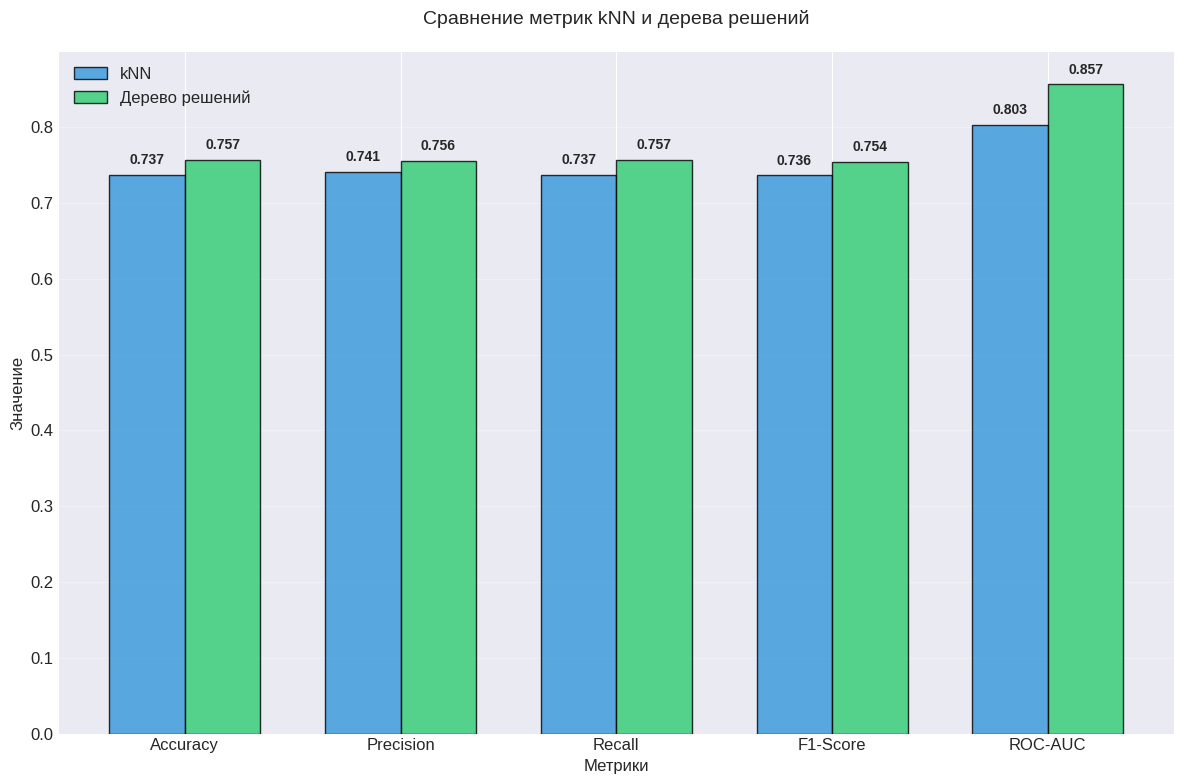


СРАВНЕНИЕ МОДЕЛЕЙ:
kNN лучше по 0 метрикам
Дерево решений лучше по 5 метрикам

СТАТИСТИКА ОШИБОК:


,Метрика,kNN,Дерево решений,Обе модели
0,Количество ошибок,40.00,37.00,20.00
1,Процент ошибок (%),26.32,24.34,13.16


In [6]:
# Сравнительный анализ
comparison_data = {
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'kNN': [
        knn_results['accuracy'],
        knn_results['precision'],
        knn_results['recall'],
        knn_results['f1'],
        knn_results['roc_auc'] if knn_results['roc_auc'] else 0
    ],
    'Дерево решений': [
        tree_results['accuracy'],
        tree_results['precision'],
        tree_results['recall'],
        tree_results['f1'],
        tree_results['roc_auc'] if tree_results['roc_auc'] else 0
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Разница'] = comparison_df['Дерево решений'] - comparison_df['kNN']

print("\nСРАВНЕНИЕ ОСНОВНЫХ МЕТРИК:")
display(comparison_df.style.format({
    'kNN': '{:.4f}',
    'Дерево решений': '{:.4f}',
    'Разница': '{:.4f}'
}).background_gradient(subset=['Разница'], cmap='RdYlGn', vmin=-0.1, vmax=0.1))

plt.figure(figsize=(12, 8))
x = np.arange(len(comparison_data['Метрика']))
width = 0.35

plt.bar(x - width/2, comparison_df['kNN'], width, label='kNN',
        color='#3498db', alpha=0.8, edgecolor='black')
plt.bar(x + width/2, comparison_df['Дерево решений'], width, label='Дерево решений',
        color='#2ecc71', alpha=0.8, edgecolor='black')

plt.xlabel('Метрики', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.title('Сравнение метрик kNN и дерева решений', fontsize=14, pad=20)
plt.xticks(x, comparison_data['Метрика'])
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

for i, (knn_val, tree_val) in enumerate(zip(comparison_df['kNN'], comparison_df['Дерево решений'])):
    plt.text(i - width/2, knn_val + 0.01, f'{knn_val:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(i + width/2, tree_val + 0.01, f'{tree_val:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

knn_wins = (comparison_df['Разница'] < 0).sum()
tree_wins = (comparison_df['Разница'] > 0).sum()

print("\nСРАВНЕНИЕ МОДЕЛЕЙ:")
print(f"kNN лучше по {knn_wins} метрикам")
print(f"Дерево решений лучше по {tree_wins} метрикам")

# Сравнение статистики ошибок
predictions_df = pd.DataFrame({
    'Истинный класс': label_encoder.inverse_transform(y_test),
    'kNN_предсказание': label_encoder.inverse_transform(knn_results['y_pred']),
    'Дерево_предсказание': label_encoder.inverse_transform(tree_results['y_pred'])
})

predictions_df['kNN_ошибка'] = predictions_df['Истинный класс'] != predictions_df['kNN_предсказание']
predictions_df['Дерево_ошибка'] = predictions_df['Истинный класс'] != predictions_df['Дерево_предсказание']
predictions_df['Обе_ошиблись'] = predictions_df['kNN_ошибка'] & predictions_df['Дерево_ошибка']

error_stats = pd.DataFrame({
    'Метрика': ['Количество ошибок', 'Процент ошибок (%)'],
    'kNN': [
        predictions_df['kNN_ошибка'].sum(),
        predictions_df['kNN_ошибка'].mean() * 100
    ],
    'Дерево решений': [
        predictions_df['Дерево_ошибка'].sum(),
        predictions_df['Дерево_ошибка'].mean() * 100
    ],
    'Обе модели': [
        predictions_df['Обе_ошиблись'].sum(),
        predictions_df['Обе_ошиблись'].mean() * 100
    ]
})

print("\nСТАТИСТИКА ОШИБОК:")
display(error_stats.style.format({
    'kNN': '{:.2f}',
    'Дерево решений': '{:.2f}',
    'Обе модели': '{:.2f}'
}))



ROC-КРИВЫЕ ДЛЯ МОДЕЛИ kNN:


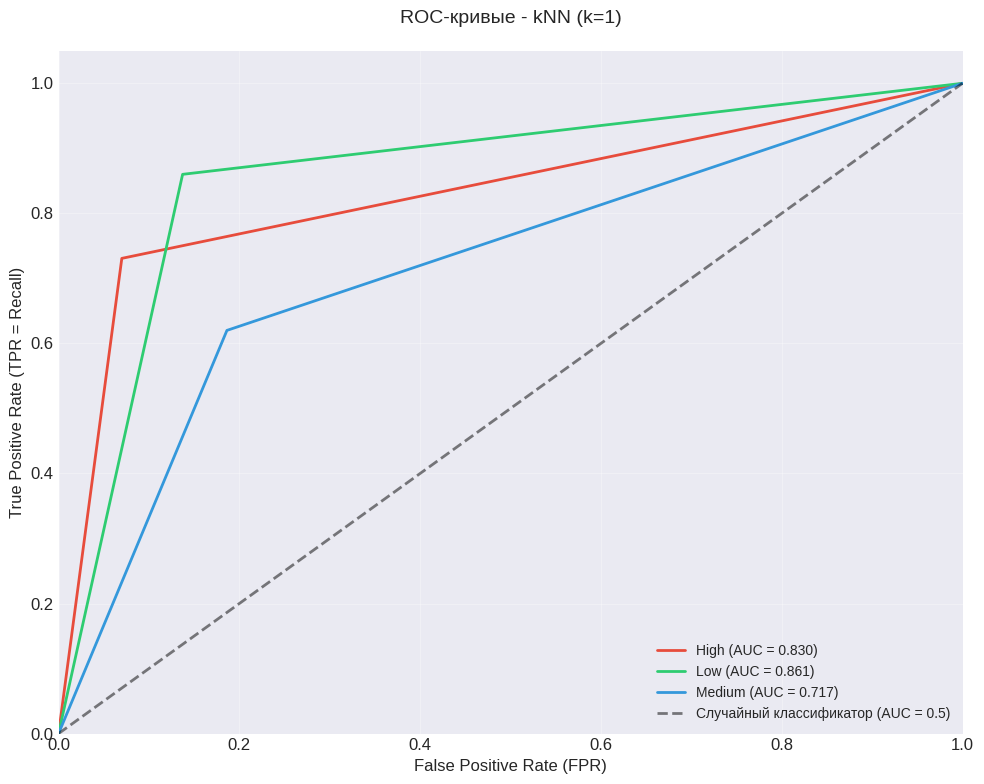


ROC-КРИВЫЕ ДЛЯ МОДЕЛИ ДЕРЕВА РЕШЕНИЙ:


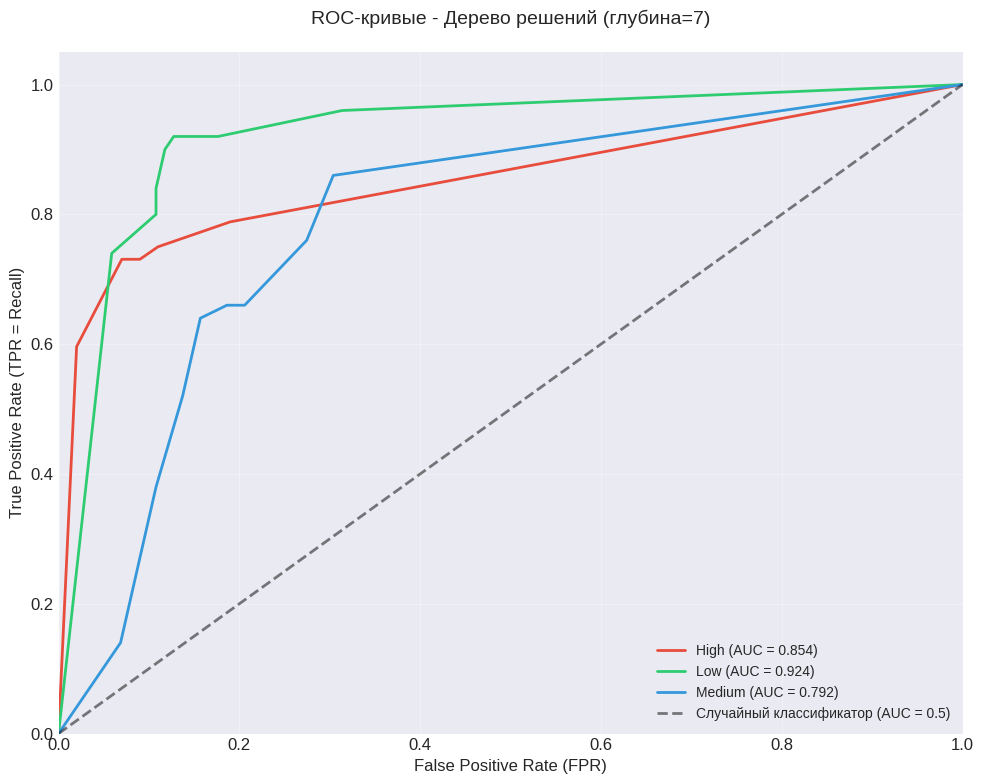


СРАВНЕНИЕ AUC ПО КЛАССАМ:


,Класс,kNN AUC,Дерево AUC,Разница
0,High,0.830,0.854,0.024
1,Low,0.861,0.924,0.062
2,Medium,0.717,0.792,0.075



СТРУКТУРА ДЕРЕВА РЕШЕНИЙ (первые 3 уровня):


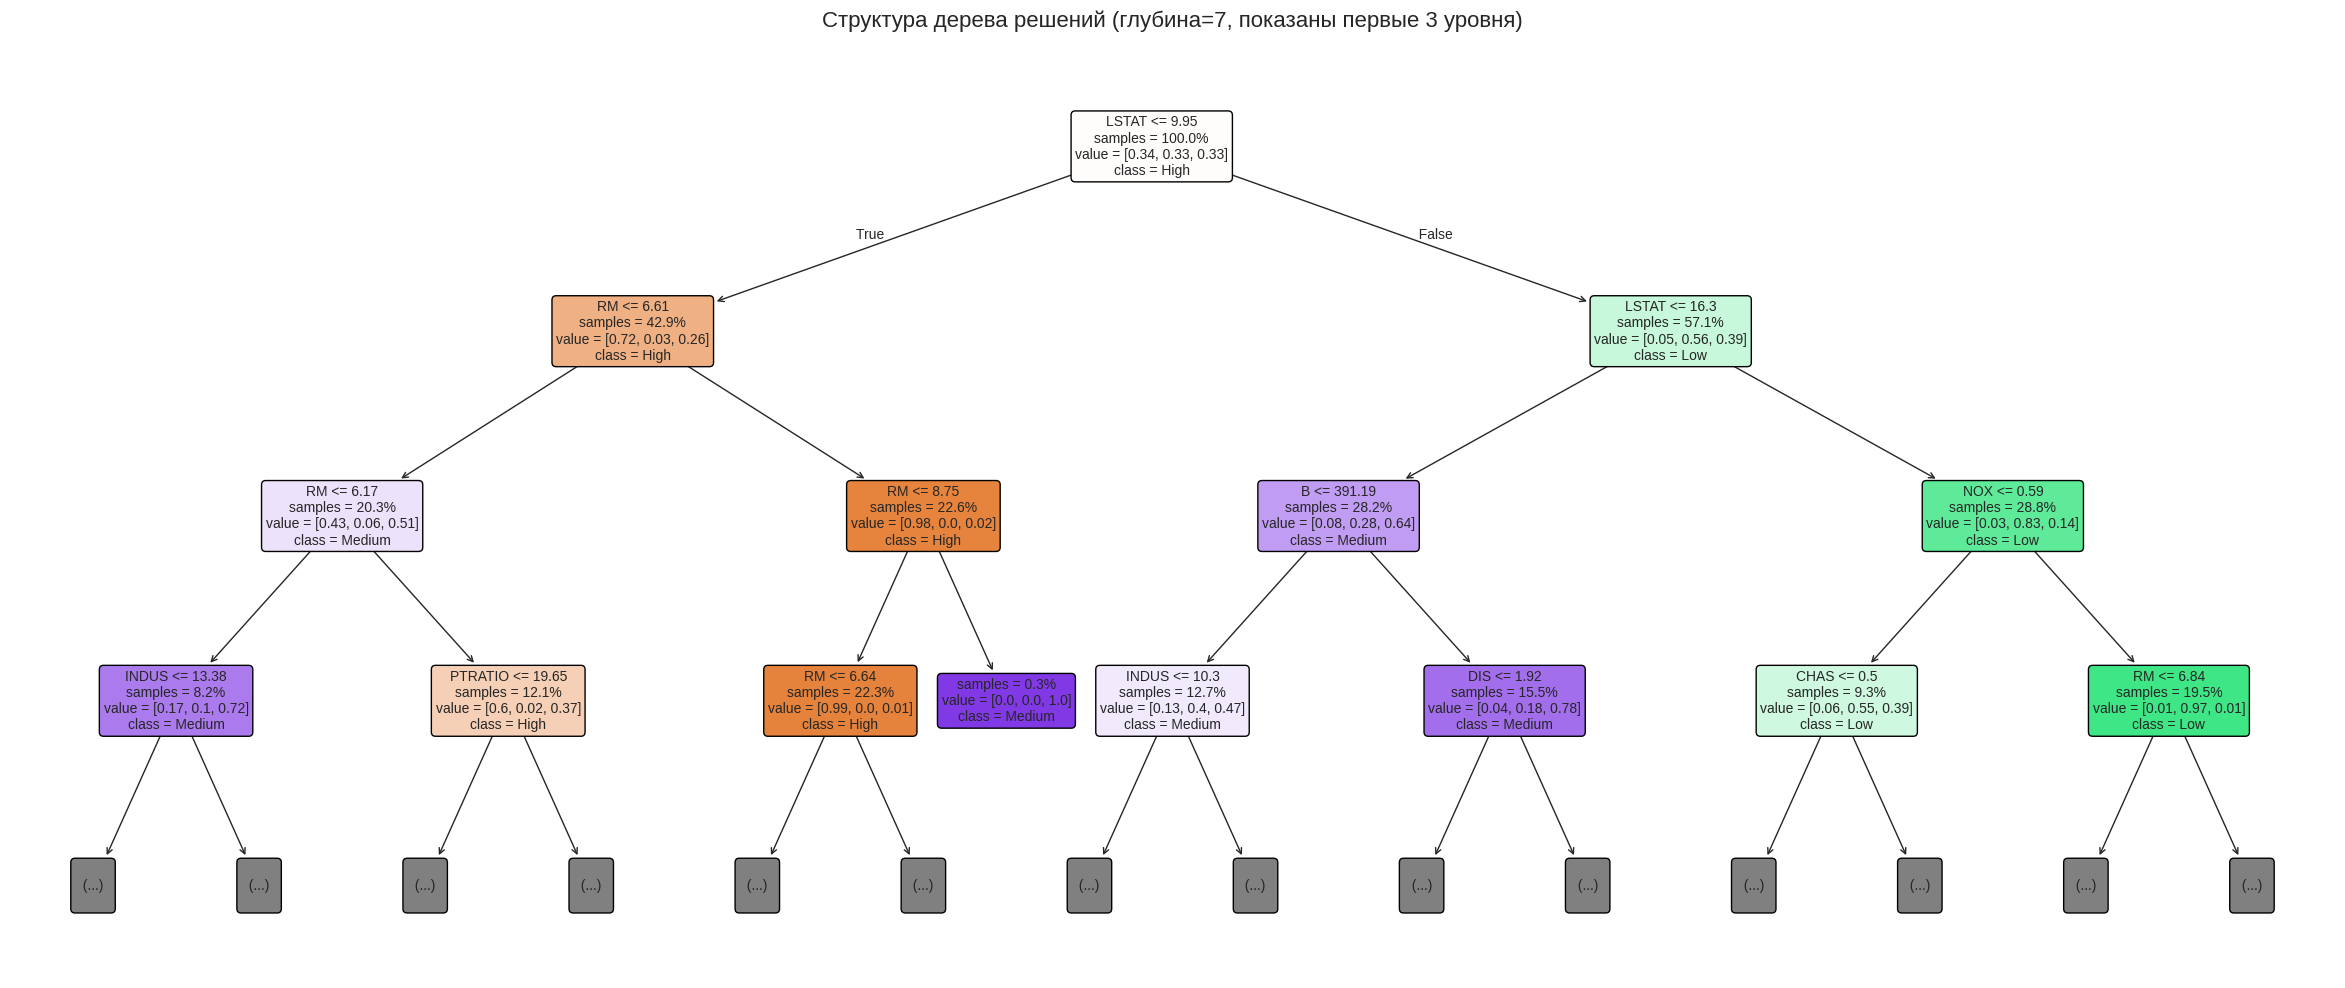

In [7]:
# ROC-кривые
def plot_multiclass_roc_curves(y_true, y_pred_proba, model_name, classes):
    n_classes = len(classes)
    fpr = {}
    tpr = {}
    roc_auc = {}

    plt.figure(figsize=(10, 8))
    colors = ['#e74c3c', '#2ecc71', '#3498db']

    for i in range(n_classes):
        # Вычисляем ROC-кривую для текущего класса
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                label=f'{classes[i]} (AUC = {roc_auc[i]:.3f})')

    # Случайный классификатор (диагональ)
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5,
             label='Случайный классификатор (AUC = 0.5)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR = Recall)', fontsize=12)
    plt.title(f'ROC-кривые - {model_name}', fontsize=14, pad=20)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return roc_auc

print("\nROC-КРИВЫЕ ДЛЯ МОДЕЛИ kNN:")
roc_auc_knn = plot_multiclass_roc_curves(
    y_test, knn_results['y_pred_proba'],
    f'kNN (k={best_k})', label_encoder.classes_
)

print("\nROC-КРИВЫЕ ДЛЯ МОДЕЛИ ДЕРЕВА РЕШЕНИЙ:")
roc_auc_tree = plot_multiclass_roc_curves(
    y_test, tree_results['y_pred_proba'],
    f'Дерево решений (глубина={best_depth})', label_encoder.classes_
)

# Сравнение AUC по классам
print("\nСРАВНЕНИЕ AUC ПО КЛАССАМ:")

auc_comparison = []
for i, cls in enumerate(label_encoder.classes_):
    auc_knn = roc_auc_knn[i] if i in roc_auc_knn else 0
    auc_tree = roc_auc_tree[i] if i in roc_auc_tree else 0
    difference = auc_tree - auc_knn

    auc_comparison.append({
        'Класс': cls,
        'kNN AUC': auc_knn,
        'Дерево AUC': auc_tree,
        'Разница': difference
    })

auc_df = pd.DataFrame(auc_comparison)
display(auc_df.style.format({
    'kNN AUC': '{:.3f}',
    'Дерево AUC': '{:.3f}',
    'Разница': '{:.3f}'
}).background_gradient(subset=['Разница'], cmap='RdYlGn', vmin=-0.1, vmax=0.1))

# Визуализация дерева решений
print("\nСТРУКТУРА ДЕРЕВА РЕШЕНИЙ (первые 3 уровня):")

plt.figure(figsize=(30, 12))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=label_encoder.classes_,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3,  # Показываем только первые 3 уровня для наглядности
          proportion=True,
          impurity=False,
          precision=2)
plt.title(f'Структура дерева решений (глубина={best_depth}, показаны первые 3 уровня)',
          fontsize=16, pad=20)
plt.show()


ТОП-5 ВАЖНЫХ ПРИЗНАКОВ ДЛЯ ДЕРЕВА РЕШЕНИЙ:


,Признак,Важность
12,LSTAT,0.455
5,RM,0.188
2,INDUS,0.065
6,AGE,0.062
10,PTRATIO,0.050


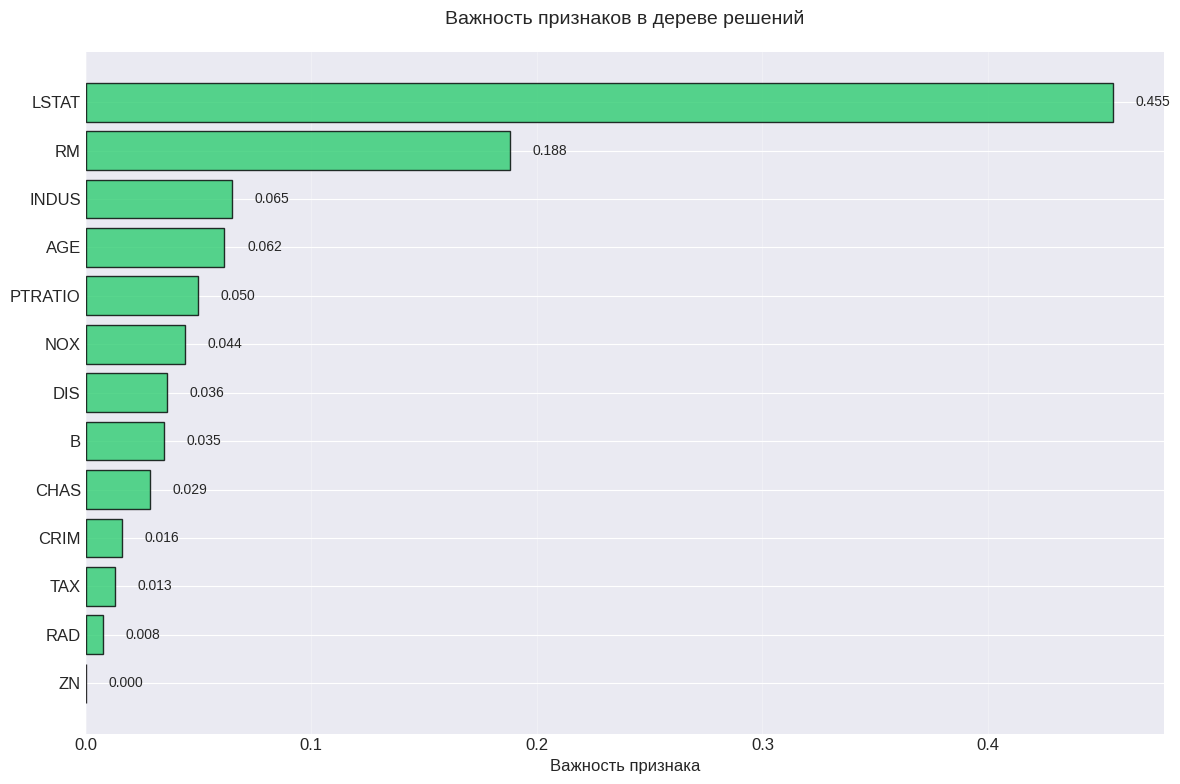

In [8]:
# Топ признаков
feature_importance = tree_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)

print("\nТОП-5 ВАЖНЫХ ПРИЗНАКОВ ДЛЯ ДЕРЕВА РЕШЕНИЙ:")
display(importance_df.tail(5).sort_values('Важность', ascending=False)
       .style.format({'Важность': '{:.3f}'}))

plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Признак'], importance_df['Важность'],
                color='#2ecc71', alpha=0.8, edgecolor='black')
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в дереве решений', fontsize=14, pad=20)
plt.grid(True, alpha=0.3, axis='x')

for i, (bar, importance) in enumerate(zip(bars, importance_df['Важность'])):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{importance:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

К наиболее важным признакам относятся % низкого статуса населения и среднее количество комнат в доме

# Выводы

В ходе исследования алгоритмов классификации на датасете Boston-house-price-data были реализованы и проанализированы два алгоритма: k-ближайших соседей (kNN) и дерево решений. Обе модели продемонстрировали хорошее качество классификации с небольшой разницей в метриках, что свидетельствует об эффективности обоих подходов для данной задачи.

Но дерево решений превосходит kNN по всем метрикам, что все-таки свидетельствуют о более высокой предсказательной способности и лучшей разделяющей способности дерева решений для данной задачи. При этом оптимальная глубина дерева составила 7 уровней, что обеспечивает баланс между сложностью модели и ее обобщающей способностью.

Оба алгоритма показали наилучшие результаты для классификации дешевых домов (Low):

kNN: 43 из 50 правильно (86%)

Дерево решений: 45 из 50 правильно (90%)

Для среднего класса (Medium) оба алгоритма испытывают наибольшие трудности:

kNN: 31 из 50 правильно (62%)

Дерево решений: 32 из 50 правильно (64%)

Высокий класс (High) классифицируется с умеренной точностью:

kNN: 38 из 52 правильно (73%)

Дерево решений: 38 из 52 правильно (73%)

Выбор оптимального k=1 для алгоритма kNN указывает на потенциальное переобучение модели, так как при таком значении модель становится чрезмерно чувствительной к шуму в данных. Несмотря на высокую точность на кросс-валидации, на тестовой выборке модель показала более низкий результат, что подтверждает гипотезу о переобучении. Это объясняет преимущество дерева решений, которое благодаря ограничению глубины (7 уровней) лучше обобщает закономерности.

Исследование подтвердило, что оба алгоритма могут успешно решать задачу классификации ценовых категорий жилья, однако дерево решений демонстрирует более высокое и стабильное качество для данного конкретного набора данных. Полученные модели могут быть использованы для автоматической категоризации объектов недвижимости, что имеет практическую ценность для риелторских компаний, банков и служб налогового оценивания.